In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

# Download latest version
path = kagglehub.dataset_download("hiteshyadavx/s-and-p-500-stock-prices")

print("Path to dataset files:", path)

/Users/clarity./anaconda3/envs/stats/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/clarity./.cache/kagglehub/datasets/hiteshyadavx/s-and-p-500-stock-prices/versions/1


# Stock Universe EDA

[*********************100%***********************]  20 of 20 completed


Skewness value 4.3609
Kurtosis value 19.2697
Worst peak-to-trough loss: -37.9684 %
Worst daily loss: -12.669 %
VaR 95% — losses no worse than: -1.9056 %
VaR 99% — losses no worse than: -3.7334 %


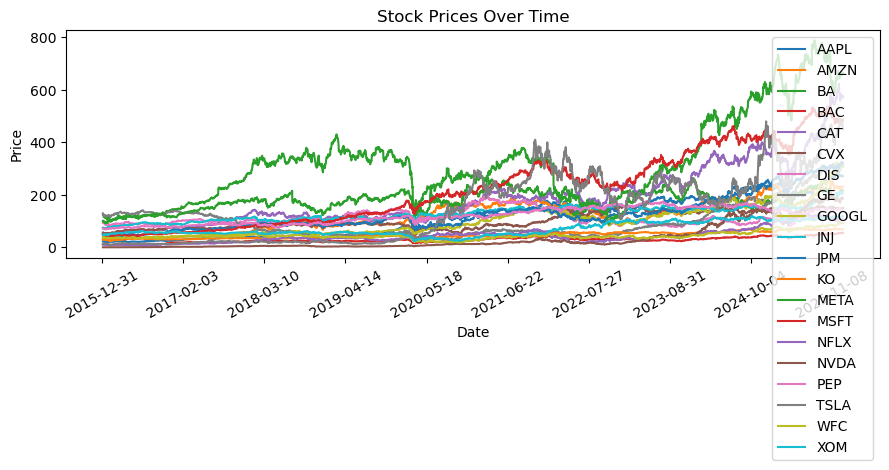

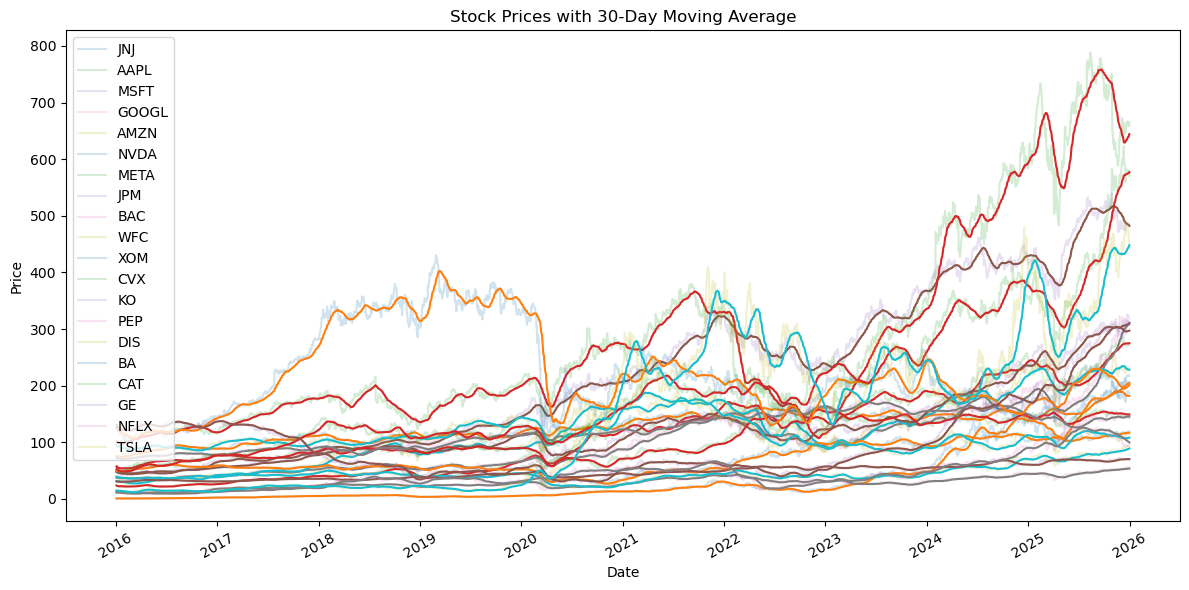

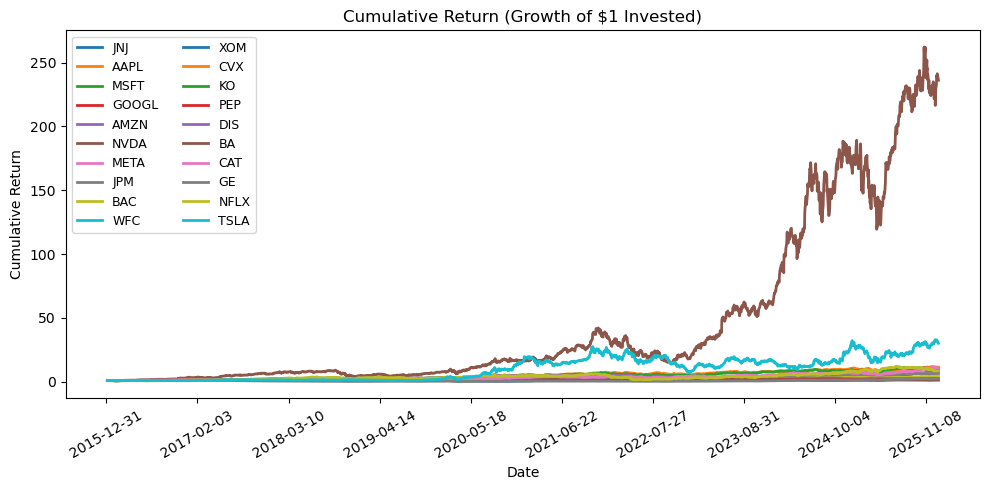

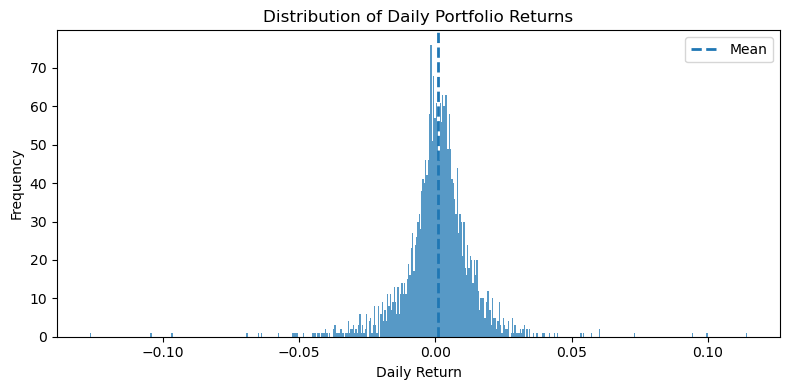

In [2]:
# =============================================================================
# IMPORTS
# =============================================================================
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# DATA LOADING
# =============================================================================

# 20 stocks (mix of growth and value stocks)
tickers = [
    "JNJ", "AAPL", "MSFT", "GOOGL", "AMZN",
    "NVDA", "META", "JPM", "BAC", "WFC",
    "XOM", "CVX", "KO", "PEP", "DIS",
    "BA", "CAT", "GE", "NFLX", "TSLA"
]

# Download closing prices (2016–2026)
df = yf.download(tickers, start="2016-01-01", end="2026-01-01")["Close"]
symbol = df.columns

# =============================================================================
# RETURN ANALYSIS
# =============================================================================

# --- Cumulative & Final Cumulative Return per Stock ---
daily_returns = df[symbol].pct_change()
cumulative_returns = (1 + daily_returns).cumprod()
final_cumulative_returns = cumulative_returns.iloc[-1] - 1
final_table = final_cumulative_returns.to_frame(name="Final Cumulative Return")
final_table.describe()

# --- Distribution Shape: Skewness & Kurtosis ---
skewness = final_cumulative_returns.skew()
kurtosis = final_cumulative_returns.kurtosis()
print("Skewness value", round(skewness, 4))   # Highly right-skewed
print("Kurtosis value", round(kurtosis, 4))   # Highly leptokurtic; driven by extreme outliers

# =============================================================================
# RISK METRICS
# =============================================================================

# --- Max Drawdown & Worst Daily Loss ---
daily_returns = df[symbol].pct_change()
portfolio_daily_return = daily_returns.mean(axis=1)
portfolio_cumulative = (1 + portfolio_daily_return).cumprod()
rolling_max = portfolio_cumulative.cummax()
drawdown = portfolio_cumulative / rolling_max - 1
worst_daily_loss = portfolio_daily_return.min()

print("Worst peak-to-trough loss:", round(drawdown.min() * 100, 4), "%")   # Max drawdown
print("Worst daily loss:",          round(worst_daily_loss * 100, 4), "%")

# --- Value at Risk (VaR): 95% and 99% Confidence ---
VaR_95 = portfolio_daily_return.quantile(0.05)
VaR_99 = portfolio_daily_return.quantile(0.01)
print("VaR 95% — losses no worse than:", round(VaR_95 * 100, 4), "%")
print("VaR 99% — losses no worse than:", round(VaR_99 * 100, 4), "%")

# =============================================================================
# VISUALIZATIONS
# =============================================================================

# --- Plot 1: Raw Stock Prices Over Time ---
plt.figure(figsize=(9, 4))
for s in symbol:
    plt.plot(df.index, df[s], label=s)
plt.legend()
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("Stock Prices Over Time")
ax = plt.gca()
ax.xaxis.set_major_locator(plt.MaxNLocator(11))
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

# --- Plot 2: Stock Prices with 30-Day Moving Average ---
df_plot = df.copy().reset_index()
window_short = 30
window_long = 90

plt.figure(figsize=(12, 6))
for s in tickers:
    plt.plot(df_plot["Date"], df_plot[s], alpha=0.2, label=s)
    plt.plot(df_plot["Date"], df_plot[s].rolling(30, min_periods=1).mean(), label="_nolegend_")
    # plt.plot(df_plot["Date"], df_plot[s].rolling(90, min_periods=1).mean(), label="_nolegend_")
plt.legend()
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("Stock Prices with 30-Day Moving Average")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# --- Plot 3: Cumulative Return (Growth of $1 Invested) ---
# Note: NVDA is a significant outlier
df_plot = df.copy().reset_index()
df_plot["Date"] = pd.to_datetime(df_plot["Date"])
symbol_no_NVDA = [s for s in tickers if s != "NVDA"]

daily_returns = df_plot[tickers].pct_change()
cumulative_returns = (1 + daily_returns).cumprod()

plt.figure(figsize=(10, 5))
for s in tickers:
    plt.plot(df_plot["Date"], cumulative_returns[s], label=s, linewidth=2)
plt.title("Cumulative Return (Growth of $1 Invested)")
plt.ylabel("Cumulative Return")
plt.xlabel("Date")
ax = plt.gca()
ax.xaxis.set_major_locator(plt.MaxNLocator(11))
plt.xticks(rotation=30)
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

# --- Plot 4: Distribution of Daily Portfolio Returns ---
daily_returns = df[symbol].pct_change()
portfolio_daily_return = daily_returns.mean(axis=1).dropna()

plt.figure(figsize=(8, 4))
plt.hist(portfolio_daily_return, bins=500, alpha=0.75)
plt.axvline(portfolio_daily_return.mean(), linestyle="--", linewidth=2, label="Mean")
plt.title("Distribution of Daily Portfolio Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()


# 20 Stock Data for PCA

[*********************100%***********************]  20 of 20 completed


Return matrix shape: 2513 days × 20 stocks

Explained Variance Ratio (Top 5 PCs):
  PC1: 0.4185  (41.85%)
  PC2: 0.1280  (12.80%)
  PC3: 0.0781  (7.81%)
  PC4: 0.0421  (4.21%)
  PC5: 0.0375  (3.75%)

PC Scores (first 2 rows):
                 PC1       PC2       PC3       PC4       PC5       PC6       PC7       PC8       PC9      PC10      PC11      PC12      PC13      PC14      PC15      PC16      PC17      PC18      PC19      PC20
Date                                                                                                                                                                                                              
2016-01-05 -0.323235 -0.675494  0.502754  0.424265 -0.045916 -0.542575 -0.773313 -0.014197 -0.645737 -0.749933  0.013680 -0.514125 -1.196803 -0.922725  0.057529  0.283541  0.325484 -0.099618 -0.261065  0.019821
2016-01-06 -2.650672  1.669447  0.453869 -0.627417 -0.395964  2.481032  2.214941  0.840870 -0.534337 -0.839431 -0.219678  0.888845 -0.050304 

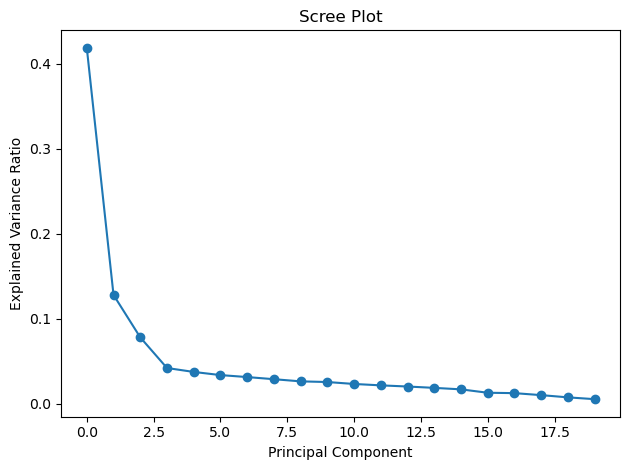


Variance Explained by First 5 PCs:
  PC       Individual    Cumulative
  ----------------------------------
  PC1         41.85%       41.85%
  PC2         12.80%       54.66%
  PC3          7.81%       62.47%
  PC4          4.21%       66.68%
  PC5          3.75%       70.42%

  Total (PC1–PC5): 70.42%


In [6]:
# =============================================================================
# IMPORTS
# =============================================================================
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# =============================================================================
# DATA LOADING
# =============================================================================

# 20 stocks (mix of growth and value stocks)
tickers = [
    "JNJ", "AAPL", "MSFT", "GOOGL", "AMZN",
    "NVDA", "META", "JPM", "BAC", "WFC",
    "XOM", "CVX", "KO", "PEP", "DIS",
    "BA", "CAT", "GE", "NFLX", "TSLA"
]

# Download closing prices (2016–2026)
prices = yf.download(tickers, start="2016-01-01", end="2026-01-01")["Close"]

# Log returns
returns = np.log(prices / prices.shift(1)).dropna()
print(f"Return matrix shape: {returns.shape[0]} days × {returns.shape[1]} stocks")

# =============================================================================
# PCA
# =============================================================================

# --- Standardize Returns ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(returns)

# --- Fit PCA ---
pca = PCA()
PCs = pca.fit_transform(X_scaled)

# --- Explained Variance ---
explained_var = pca.explained_variance_ratio_
print("\nExplained Variance Ratio (Top 5 PCs):")
for i, v in enumerate(explained_var[:5], 1):
    print(f"  PC{i}: {v:.4f}  ({v*100:.2f}%)")

# --- PC Scores DataFrame ---
pc_df = pd.DataFrame(
    PCs,
    index=returns.index,
    columns=[f"PC{i+1}" for i in range(PCs.shape[1])]
)
print("\nPC Scores (first 2 rows):")
print(pc_df.head(2).to_string())

# =============================================================================
# LOADINGS
# =============================================================================

loadings = pd.DataFrame(
    pca.components_.T,
    index=returns.columns,
    columns=[f"PC{i+1}" for i in range(len(returns.columns))]
)

print("\nPC1 Loadings (sorted high → low):")
print(loadings["PC1"].sort_values(ascending=False).to_string())

print("\nPC2 Loadings:")
print(loadings["PC2"].to_string())

# =============================================================================
# SCREE PLOT & EXPLAINED VARIANCE
# =============================================================================

# --- Scree Plot ---
plt.figure()
plt.plot(explained_var, marker='o')
plt.title("Scree Plot")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.tight_layout()
plt.show()

# --- Cumulative Variance Explained by First 5 PCs ---
cum_var_5 = pca.explained_variance_ratio_[:5].sum()

print("\nVariance Explained by First 5 PCs:")
print(f"  {'PC':<6} {'Individual':>12}  {'Cumulative':>12}")
print(f"  {'-'*34}")
cumulative = 0
for i, v in enumerate(pca.explained_variance_ratio_[:5], 1):
    cumulative += v
    print(f"  PC{i:<4} {v*100:>10.2f}%  {cumulative*100:>10.2f}%")
print(f"\n  Total (PC1–PC5): {cum_var_5*100:.2f}%")


# Apple Regression Model

In [7]:
import statsmodels.api as sm

y = returns["AAPL"]
X = pc_df[["PC1", "PC2"]]

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   AAPL   R-squared:                       0.629
Model:                            OLS   Adj. R-squared:                  0.629
Method:                 Least Squares   F-statistic:                     2127.
Date:                Wed, 13 May 2026   Prob (F-statistic):               0.00
Time:                        22:31:15   Log-Likelihood:                 7737.1
No. Observations:                2513   AIC:                        -1.547e+04
Df Residuals:                    2510   BIC:                        -1.545e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0010      0.000      4.365      0.0

# Fama-French Validation

FF3 aligned:  2513 days  |  cols: ['Mkt-RF', 'SMB', 'HML', 'RF']
FF5 aligned:  2513 days  |  cols: ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']


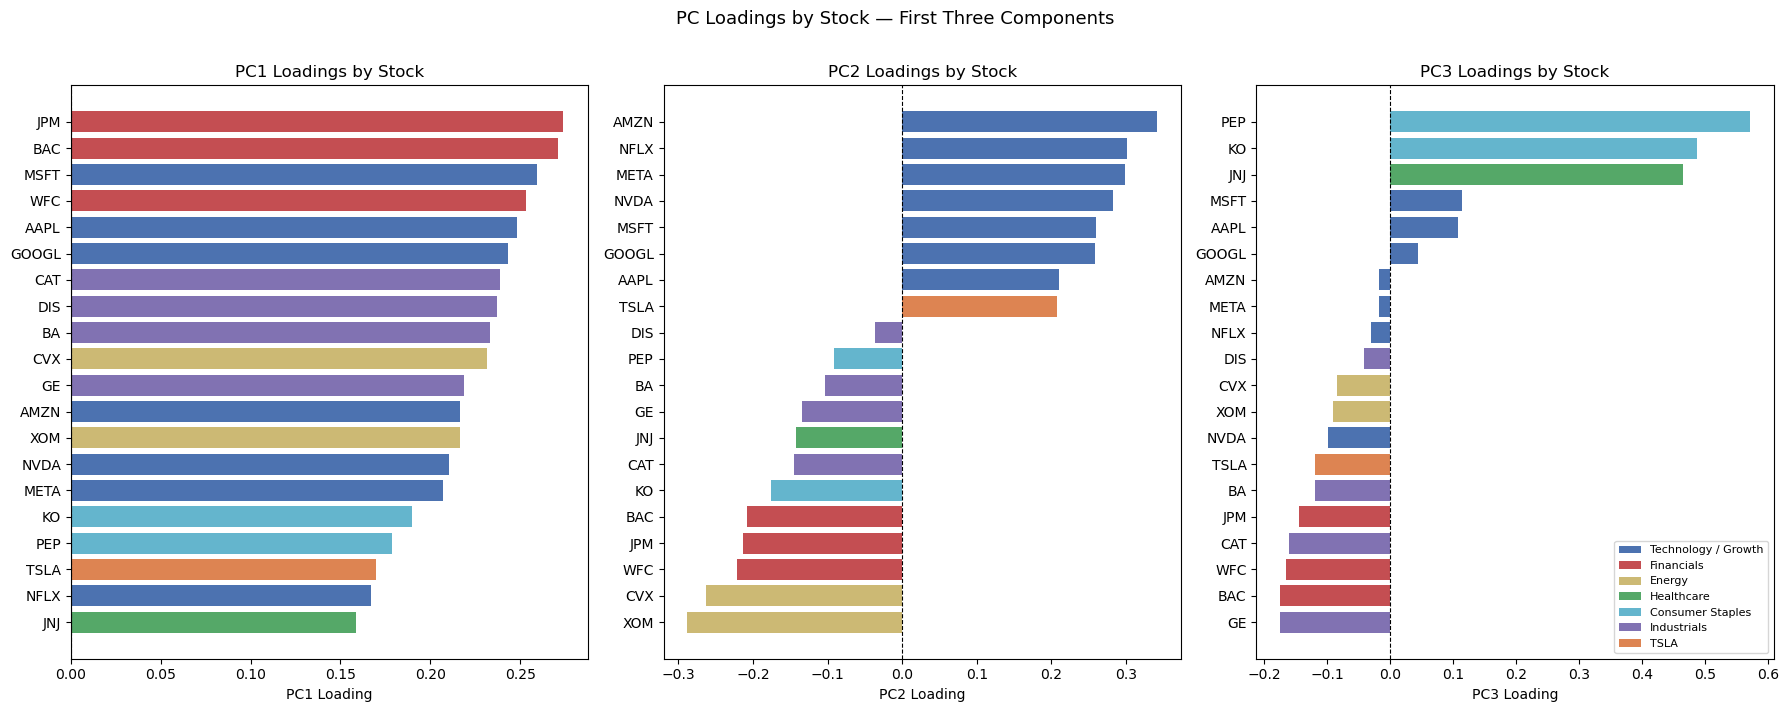

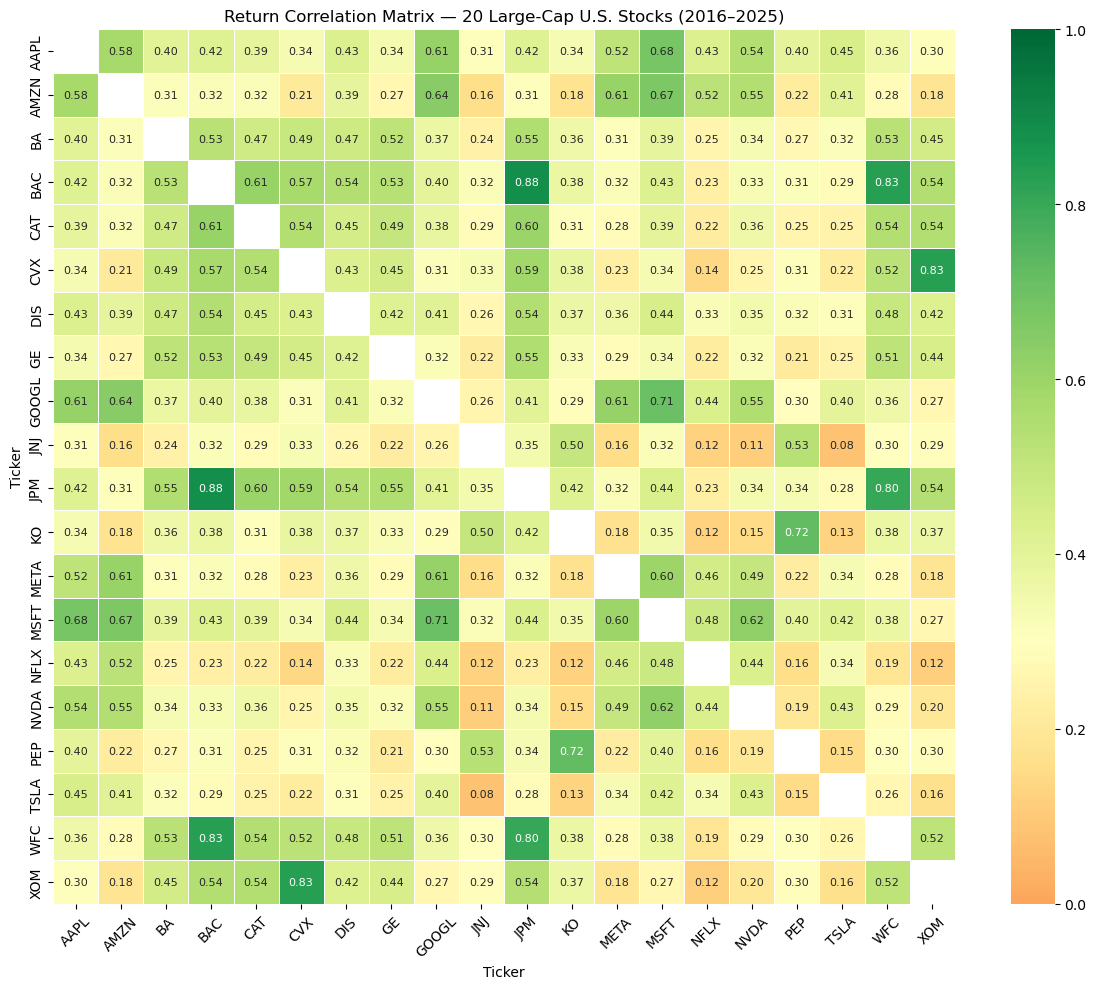

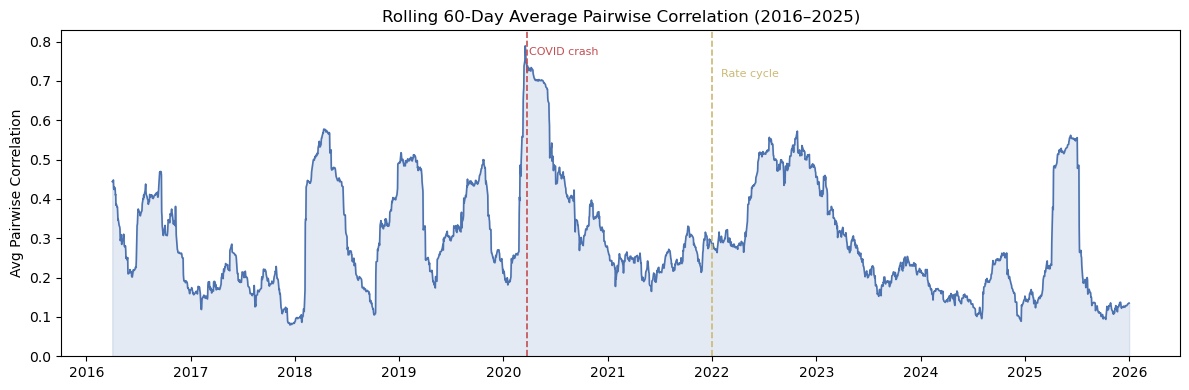


  FF3 REGRESSION SUMMARY  (factors: Mkt-RF, SMB, HML)
 PC  R_squared  Adj_R_squared  F_pvalue  Mkt-RF_coef  Mkt-RF_tstat  SMB_coef  SMB_tstat  HML_coef  HML_tstat
PC1     0.9458         0.9458    0.0000      243.905        205.61   -30.621     -14.80    49.935      33.89
PC2     0.6501         0.6497    0.0000        7.649          4.59    -0.937      -0.32  -139.605     -67.39
PC3     0.1458         0.1448    0.0000        9.915          4.87   -62.636     -17.64   -25.723     -10.17
PC4     0.0058         0.0046    0.0023       -1.408         -0.87     0.576       0.20    -7.563      -3.78
PC5     0.0222         0.0210    0.0000       -2.038         -1.35    16.882       6.42    -7.688      -4.10

  DETAILED OLS — PC1 on FF3 (Mkt-RF, SMB, HML)
                            OLS Regression Results                            
Dep. Variable:                    PC1   R-squared:                       0.946
Model:                            OLS   Adj. R-squared:                  0.946
Method

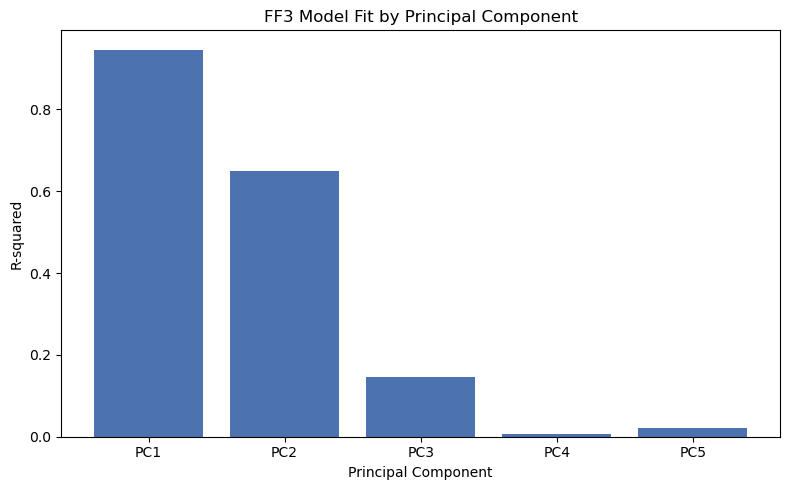

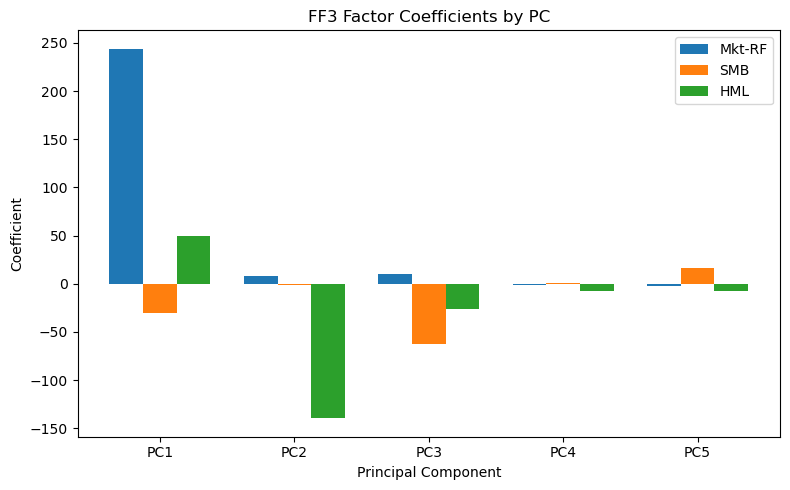

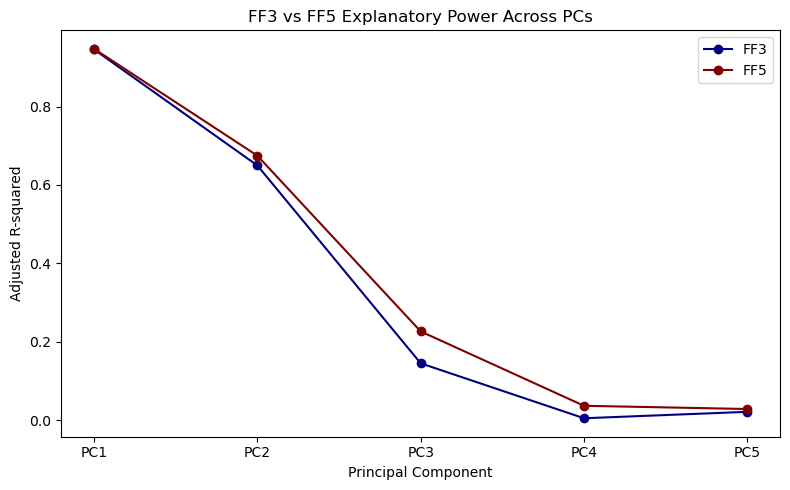

[*********************100%***********************]  1 of 1 completed


  PC1 CORRELATIONS WITH MARKET PROXIES
  SPY                         r = 0.9601
  Equal_Weight_Portfolio      r = 0.9909
  Mkt_RF                      r = 0.9576


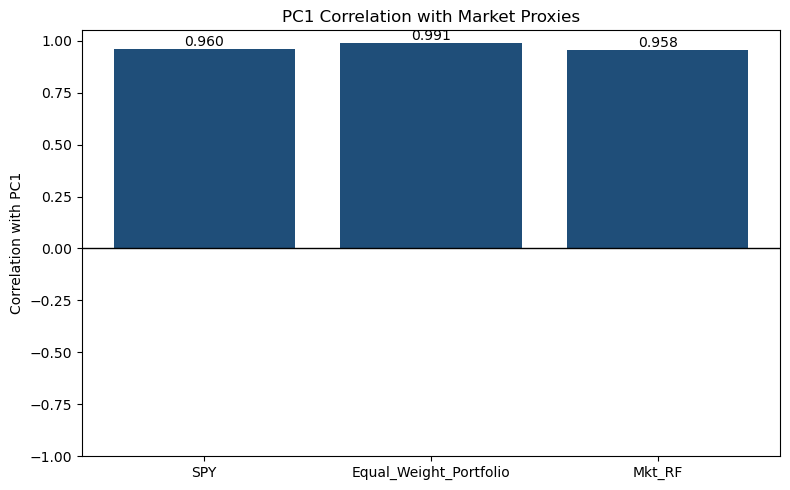


  PC2 CORRELATIONS WITH FF5 STYLE FACTORS
  Mkt_RF      r = 0.1264
  SMB         r = -0.2502
  HML         r = -0.8044
  RMW         r = -0.2128
  CMA         r = -0.5671


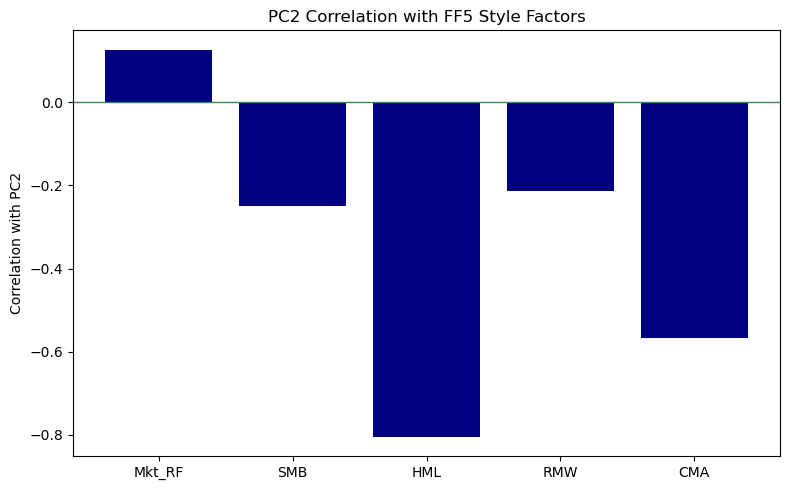

In [8]:
# =============================================================================
# IMPORTS
# =============================================================================
import pandas as pd
import numpy as np
import urllib.request
import zipfile
import io
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# =============================================================================
# FAMA-FRENCH DATA LOADING
# =============================================================================

start_date = returns.index.min()
end_date   = returns.index.max()

# --- FF3: Market, SMB, HML ---
url3 = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_Factors_daily_CSV.zip"
with urllib.request.urlopen(url3) as response:
    z = zipfile.ZipFile(io.BytesIO(response.read()))
    fname = [f for f in z.namelist() if f.lower().endswith('.csv')][0]
    with z.open(fname) as f:
        raw = pd.read_csv(f, skiprows=4, index_col=0)

raw = raw[pd.to_numeric(raw.iloc[:, 0], errors='coerce').notna()]
raw.index = pd.to_datetime(raw.index, format='%Y%m%d')
raw = raw.astype(float) / 100.0
raw.index.name = 'Date'
raw.columns = ['Mkt-RF', 'SMB', 'HML', 'RF']
ff3 = raw.loc[start_date:end_date].reindex(pc_df.index).dropna()

# --- FF5: Market, SMB, HML, RMW, CMA ---
url5 = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_5_Factors_2x3_daily_CSV.zip"
with urllib.request.urlopen(url5) as response:
    z = zipfile.ZipFile(io.BytesIO(response.read()))
    fname = [f for f in z.namelist() if f.lower().endswith('.csv')][0]
    with z.open(fname) as f:
        raw5 = pd.read_csv(f, skiprows=3, index_col=0)

raw5 = raw5[pd.to_numeric(raw5.iloc[:, 0], errors='coerce').notna()]
raw5.index = pd.to_datetime(raw5.index, format='%Y%m%d')
raw5 = raw5.astype(float) / 100.0
raw5.index.name = 'Date'
raw5.columns = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']
ff5_aligned = raw5.loc[start_date:end_date].reindex(pc_df.index).dropna()

print(f"FF3 aligned:  {ff3.shape[0]} days  |  cols: {list(ff3.columns)}")
print(f"FF5 aligned:  {ff5_aligned.shape[0]} days  |  cols: {list(ff5_aligned.columns)}")

# =============================================================================
# SECTOR COLOR MAP
# =============================================================================

TECH     = "#4C72B0"
FIN      = "#C44E52"
ENERGY   = "#CCB974"
HEALTH   = "#55A868"
STAPLES  = "#64B5CD"
IND      = "#8172B2"
TSLA_COL = "#DD8452"

sector_colors = {
    "AAPL": TECH,  "MSFT": TECH,  "GOOGL": TECH,
    "AMZN": TECH,  "NVDA": TECH,  "META":  TECH,  "NFLX": TECH,
    "JPM":  FIN,   "BAC":  FIN,   "WFC":   FIN,
    "XOM":  ENERGY,"CVX":  ENERGY,
    "JNJ":  HEALTH,
    "KO":   STAPLES,"PEP": STAPLES,
    "DIS":  IND,   "BA":   IND,   "CAT":   IND,   "GE":   IND,
    "TSLA": TSLA_COL
}

legend_elements = [
    Patch(facecolor=TECH,     label="Technology / Growth"),
    Patch(facecolor=FIN,      label="Financials"),
    Patch(facecolor=ENERGY,   label="Energy"),
    Patch(facecolor=HEALTH,   label="Healthcare"),
    Patch(facecolor=STAPLES,  label="Consumer Staples"),
    Patch(facecolor=IND,      label="Industrials"),
    Patch(facecolor=TSLA_COL, label="TSLA"),
]

# =============================================================================
# VISUALIZATIONS
# =============================================================================

# --- Plot 1: PC1–PC3 Loadings Bar Chart (Color-coded by Sector) ---
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
for ax, pc_name in zip(axes, ["PC1", "PC2", "PC3"]):
    pc = loadings[pc_name].sort_values()
    colors = [sector_colors[t] for t in pc.index]
    ax.barh(pc.index, pc.values, color=colors)
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xlabel(f"{pc_name} Loading")
    ax.set_title(f"{pc_name} Loadings by Stock")
axes[2].legend(handles=legend_elements, loc="lower right", fontsize=8)
plt.suptitle("PC Loadings by Stock — First Three Components", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("pc123_loadings.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Plot 2: Return Correlation Matrix Heatmap ---
corr = returns.corr()
mask = np.eye(len(corr), dtype=bool)
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="RdYlGn", center=0.3, vmin=0, vmax=1,
            linewidths=0.5, linecolor="white",
            annot_kws={"size": 8}, ax=ax)
ax.set_title("Return Correlation Matrix — 20 Large-Cap U.S. Stocks (2016–2025)")
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig("corr_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Plot 3: Rolling 60-Day Average Pairwise Correlation ---
window = 60
rolling_corr = []
for i in range(window, len(returns)):
    window_data = returns.iloc[i - window:i]
    corr_vals = window_data.corr().values
    upper = corr_vals[np.triu_indices_from(corr_vals, k=1)]
    rolling_corr.append(upper.mean())

rolling_corr_series = pd.Series(rolling_corr, index=returns.index[window:])

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(rolling_corr_series.index, rolling_corr_series.values, color="#4C72B0", linewidth=1.2)
ax.fill_between(rolling_corr_series.index, rolling_corr_series.values, alpha=0.15, color="#4C72B0")
ax.axvline(pd.Timestamp("2020-03-23"), color="#C44E52", linestyle="--", linewidth=1.2)
ax.text(pd.Timestamp("2020-04-01"), rolling_corr_series.max() * 0.97, "COVID crash", fontsize=8, color="#C44E52")
ax.axvline(pd.Timestamp("2022-01-01"), color="#CCB974", linestyle="--", linewidth=1.2)
ax.text(pd.Timestamp("2022-02-01"), rolling_corr_series.max() * 0.90, "Rate cycle", fontsize=8, color="#CCB974")
ax.set_title("Rolling 60-Day Average Pairwise Correlation (2016–2025)")
ax.set_ylabel("Avg Pairwise Correlation")
ax.set_ylim(0, None)
plt.tight_layout()
plt.savefig("rolling_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

# =============================================================================
# FAMA-FRENCH REGRESSION
# =============================================================================

def regress_pcs_on_factors(pc_df, factor_df, factor_cols, n_pcs=5):
    rows = []
    for i in range(1, n_pcs + 1):
        pc_name = f"PC{i}"
        y = pc_df[pc_name]
        X = factor_df[factor_cols]
        common = y.index.intersection(X.index)
        y, X = y.loc[common], X.loc[common]
        model = sm.OLS(y, sm.add_constant(X)).fit()
        row = {
            "PC": pc_name,
            "R_squared":     round(model.rsquared, 4),
            "Adj_R_squared": round(model.rsquared_adj, 4),
            "F_pvalue":      round(model.f_pvalue, 4),
        }
        for c in factor_cols:
            row[f"{c}_coef"]  = round(model.params[c], 3)
            row[f"{c}_tstat"] = round(model.tvalues[c], 2)
        rows.append(row)
    return pd.DataFrame(rows)

# --- FF3 Summary ---
ff3_cols = ["Mkt-RF", "SMB", "HML"]
summary_ff3 = regress_pcs_on_factors(pc_df, ff3, ff3_cols, n_pcs=5)

print("\n" + "=" * 70)
print("  FF3 REGRESSION SUMMARY  (factors: Mkt-RF, SMB, HML)")
print("=" * 70)
print(summary_ff3.to_string(index=False))

# --- FF3 Detailed OLS per PC ---
for i in range(1, 6):
    pc_name = f"PC{i}"
    y = pc_df[pc_name].loc[ff3.index]
    model = sm.OLS(y, sm.add_constant(ff3[ff3_cols])).fit()
    print("\n" + "=" * 70)
    print(f"  DETAILED OLS — {pc_name} on FF3 (Mkt-RF, SMB, HML)")
    print("=" * 70)
    print(model.summary())

# --- FF5 Summary ---
ff5_cols = ["Mkt-RF", "SMB", "HML", "RMW", "CMA"]
summary_ff5 = regress_pcs_on_factors(pc_df, ff5_aligned, ff5_cols, n_pcs=5)

print("\n" + "=" * 70)
print("  FF5 REGRESSION SUMMARY  (factors: Mkt-RF, SMB, HML, RMW, CMA)")
print("=" * 70)
print(summary_ff5.to_string(index=False))

# --- FF3 vs FF5 Adj-R² Comparison Table ---
ff_comparison = summary_ff3[["PC", "Adj_R_squared"]].rename(
    columns={"Adj_R_squared": "FF3_Adj_R_squared"}
).copy()
ff_comparison["FF5_Adj_R_squared"] = summary_ff5["Adj_R_squared"]
ff_comparison["Adj_R2_Improvement"] = (
    ff_comparison["FF5_Adj_R_squared"] - ff_comparison["FF3_Adj_R_squared"]
).round(4)

print("\n" + "=" * 70)
print("  FF3 vs FF5 — Adjusted R² Comparison")
print("=" * 70)
print(ff_comparison.to_string(index=False))

# =============================================================================
# REGRESSION VISUALIZATIONS
# =============================================================================

# --- Plot 4: FF3 R² by PC ---
plt.figure(figsize=(8, 5))
plt.bar(summary_ff3["PC"], summary_ff3["R_squared"], color="#4C72B0")
plt.xlabel("Principal Component")
plt.ylabel("R-squared")
plt.title("FF3 Model Fit by Principal Component")
plt.tight_layout()
plt.show()

# --- Plot 5: FF3 Factor Coefficients by PC ---
x = np.arange(len(summary_ff3["PC"]))
width = 0.25
plt.figure(figsize=(8, 5))
plt.bar(x - width, summary_ff3["Mkt-RF_coef"], width, label="Mkt-RF")
plt.bar(x,         summary_ff3["SMB_coef"],    width, label="SMB")
plt.bar(x + width, summary_ff3["HML_coef"],    width, label="HML")
plt.xticks(x, summary_ff3["PC"])
plt.xlabel("Principal Component")
plt.ylabel("Coefficient")
plt.title("FF3 Factor Coefficients by PC")
plt.legend()
plt.tight_layout()
plt.show()

# --- Plot 6: FF3 vs FF5 Adj-R² ---
plt.figure(figsize=(8, 5))
plt.plot(ff_comparison["PC"], ff_comparison["FF3_Adj_R_squared"], marker="o", label="FF3", color="navy")
plt.plot(ff_comparison["PC"], ff_comparison["FF5_Adj_R_squared"], marker="o", label="FF5", color="maroon")
plt.xlabel("Principal Component")
plt.ylabel("Adjusted R-squared")
plt.title("FF3 vs FF5 Explanatory Power Across PCs")
plt.legend()
plt.tight_layout()
plt.show()

# =============================================================================
# PC1 vs MARKET PROXIES
# =============================================================================

spy_price          = yf.download(["SPY"], start="2016-01-01", end="2026-01-01")["Close"]
spy_return         = np.log(spy_price / spy_price.shift(1)).dropna()
equal_weight_return = returns.mean(axis=1)

market_check = pd.concat([
    pc_df["PC1"],
    spy_return["SPY"],
    equal_weight_return.rename("Equal_Weight_Portfolio"),
    ff5_aligned["Mkt-RF"]
], axis=1, join="inner").dropna()
market_check.columns = ["PC1", "SPY", "Equal_Weight_Portfolio", "Mkt_RF"]

pc1_corr = market_check.corr().loc["PC1", ["SPY", "Equal_Weight_Portfolio", "Mkt_RF"]]

print("\n" + "=" * 70)
print("  PC1 CORRELATIONS WITH MARKET PROXIES")
print("=" * 70)
for name, val in pc1_corr.items():
    print(f"  {name:<26}  r = {val:.4f}")

# --- Plot 7: PC1 vs Market Proxies Bar Chart ---
plt.figure(figsize=(8, 5))
bars = plt.bar(pc1_corr.index, pc1_corr.values, color="#1f4e79")
plt.axhline(0, linewidth=1, color="black")
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, h, f"{h:.3f}", ha="center", va="bottom")
plt.ylabel("Correlation with PC1")
plt.title("PC1 Correlation with Market Proxies")
plt.ylim(-1, 1.05)
plt.tight_layout()
plt.show()

# =============================================================================
# PC2 vs FAMA-FRENCH STYLE FACTORS
# =============================================================================

pc2_style_check = pd.concat([
    pc_df["PC2"],
    ff5_aligned[["Mkt-RF", "SMB", "HML", "RMW", "CMA"]].rename(columns={"Mkt-RF": "Mkt_RF"})
], axis=1, join="inner").dropna()

pc2_corr = pc2_style_check.corr().loc["PC2", ["Mkt_RF", "SMB", "HML", "RMW", "CMA"]]

print("\n" + "=" * 70)
print("  PC2 CORRELATIONS WITH FF5 STYLE FACTORS")
print("=" * 70)
for name, val in pc2_corr.items():
    print(f"  {name:<10}  r = {val:.4f}")

# --- Plot 8: PC2 vs FF5 Factors Bar Chart ---
plt.figure(figsize=(8, 5))
plt.bar(pc2_corr.index, pc2_corr.values, color="navy")
plt.axhline(0, linewidth=1, color="seagreen")
plt.ylabel("Correlation with PC2")
plt.title("PC2 Correlation with FF5 Style Factors")
plt.tight_layout()
plt.show()


# Fehmeen:

Portfolio Optimization via PCA Factor Model

PCA based covariance matrix

Building on PCA decomposition and Fama-French analysis, we use the
first 5 principal components to construct a factor-based covariance matrix and solve
for the efficient frontier across our 20-stock universe.

In [ ]:
# !pip install cvxpy
import cvxpy as cp

# PCs to use as per our scree plot
k=5

# Factor covariance: Cov(F) is just diagonal since PCs are orthogonal
factor_var = np.diag(pca.explained_variance_[:k])   # k×k diagonal matrix

# Loadings for the first k PCs (20 stocks × k), # how much each stock is exposed to each PC
L = pca.components_[:k].T   # shape: (20, k)


# Idiosyncratic variance: what's left after the k factors
returns_scaled = scaler.transform(returns)           # using same scaler as before
reconstructed  = returns_scaled @ L @ np.linalg.pinv(L.T @ L) @ L.T
residuals      = returns_scaled - reconstructed
D              = np.diag(np.var(residuals, axis=0))  # diagonal residual matrix


# Factor-model covariance matrix (in standardized space)
Sigma_factor = L @ factor_var @ L.T + D

# Convert back to return space using the scaler's std
std_vec  = scaler.scale_          # per-stock std of log returns
outer_std = np.outer(std_vec, std_vec)
Sigma     = Sigma_factor * outer_std      # final 20×20 covariance matrix

# Raw sample covariance (for comparison later)
Sigma_sample = returns.cov().values


print("Factor covariance matrix shape:", Sigma.shape)
print("Condition number (factor):", round(np.linalg.cond(Sigma), 1))
print("Condition number (sample):", round(np.linalg.cond(Sigma_sample), 1))
# Lower condition number = more stable/well-behaved matrix


# Annualized mean log return for each stock
mu = returns.mean().values * 252          # 252 trading days
mu_df = pd.Series(mu, index=tickers)

print("Expected Annual Returns:")
print(mu_df.round(4).sort_values(ascending=False))







## Efficient Frontier Function

In [ ]:
def efficient_frontier(mu, Sigma, n_points=200, risk_free=None):
    """
    Sweep across target returns and solve for minimum-variance portfolio.
    Returns arrays of portfolio volatility, return, and weights.
    """
    n = len(mu)
    target_returns = np.linspace(mu.min(), mu.max(), n_points)

    port_vols    = []
    port_rets    = []
    port_weights = []

    for target in target_returns:
        w = cp.Variable(n)
        objective   = cp.Minimize(cp.quad_form(w, cp.psd_wrap(Sigma)))
        constraints = [
            cp.sum(w) == 1,       # fully invested
            w >= 0,               # long-only
            w <= 0.25,             # no single stock can take more than 25%,
            mu @ w >= target      # hit the target return
        ]
        prob = cp.Problem(objective, constraints)
        prob.solve(solver=cp.CLARABEL, warm_start=True)

        if prob.status in ("optimal", "optimal_inaccurate"):
            port_vols.append(np.sqrt(prob.value * 252))   # annualized vol
            port_rets.append(float(mu @ w.value))
            port_weights.append(w.value)

    return np.array(port_vols), np.array(port_rets), port_weights

### Efficient Frontier
The frontier traces the best possible return for every level of risk across all
possible combinations of our 20 stocks. A 25% position cap per stock is imposed
to ensure realistic diversification. Three key portfolios are highlighted:
- **Minimum Variance Portfolio**: lowest achievable risk (~16% vol, ~11% return, Sharpe: 0.533)
- **Tangency Portfolio**: highest Sharpe ratio (~25% vol, ~29% return, Sharpe: 1.096)
- **Equal-Weight Benchmark**: naive 5% allocation to each stock (Sharpe: 0.700),
  which sits visibly inside the frontier — meaning optimization strictly dominates it

The PCA factor frontier and raw sample covariance frontier nearly overlap,
reflecting that 10 years of daily data across 20 stocks is sufficient for
stable covariance estimation.

Solving both frontiers

In [ ]:
# Risk-free rate: use average RF from your FF5 data
rf_annual = ff5_aligned["RF"].mean() * 252

print(f"Risk-free rate (annualized): {rf_annual:.4f}")

# Frontier using PCA factor covariance ─────────────────────────────────────
vols_pca, rets_pca, weights_pca = efficient_frontier(mu, Sigma, risk_free=rf_annual)

# Frontier using raw sample covariance ─────────────────────────────────────
vols_raw, rets_raw, weights_raw = efficient_frontier(mu, Sigma_sample, risk_free=rf_annual)

print("Points on PCA frontier:", len(vols_pca))
print("Points on sample frontier:   ", len(vols_raw))

Finding key portfolios

In [ ]:
def tangency_portfolio(vols, rets, rf):
    """Find the portfolio with the highest Sharpe ratio (tangency point)."""
    sharpe = (rets - rf) / vols
    idx    = np.argmax(sharpe)
    return idx

def min_variance_portfolio(vols):
    """Find the minimum variance portfolio."""
    return np.argmin(vols)

#  PCA frontier key points
idx_mvp_pca  = min_variance_portfolio(vols_pca)
idx_tan_pca  = tangency_portfolio(vols_pca, rets_pca, rf_annual)

# Equal-weight portfolio as benchmark
ew_weights   = np.ones(len(tickers)) / len(tickers)
ew_ret       = float(mu @ ew_weights)
ew_vol       = float(np.sqrt(ew_weights @ Sigma @ ew_weights * 252))
ew_sharpe    = (ew_ret - rf_annual) / ew_vol

print(f"{'Portfolio':<30} {'Ann. Return':>12} {'Ann. Vol':>10} {'Sharpe':>8}")
print("-" * 65)
print(f"{'MVP  (PCA frontier)':<30} {rets_pca[idx_mvp_pca]:>12.4f} {vols_pca[idx_mvp_pca]:>10.4f} "
      f"{(rets_pca[idx_mvp_pca]-rf_annual)/vols_pca[idx_mvp_pca]:>8.3f}")
print(f"{'Tangency (PCA frontier)':<30} {rets_pca[idx_tan_pca]:>12.4f} {vols_pca[idx_tan_pca]:>10.4f} "
      f"{(rets_pca[idx_tan_pca]-rf_annual)/vols_pca[idx_tan_pca]:>8.3f}")
print(f"{'Equal-Weight Benchmark':<30} {ew_ret:>12.4f} {ew_vol:>10.4f} {ew_sharpe:>8.3f}")

Plot the efficient frontier

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

# Both frontiers
ax.plot(vols_pca, rets_pca, color="navy",   linewidth=2, label="PCA Factor Covariance")
ax.plot(vols_raw, rets_raw, color="firebrick", linewidth=2,
        linestyle="--", label="Sample Covariance")

# Key portfolios on PCA frontier
ax.scatter(vols_pca[idx_mvp_pca], rets_pca[idx_mvp_pca],
           marker="*", s=250, color="gold", zorder=5, label="Min Variance (PCA)")
ax.scatter(vols_pca[idx_tan_pca], rets_pca[idx_tan_pca],
           marker="*", s=250, color="limegreen", zorder=5, label="Tangency / Max Sharpe (PCA)")

# Equal-weight benchmark
ax.scatter(ew_vol, ew_ret, marker="D", s=100, color="orange",
           zorder=5, label="Equal-Weight Portfolio")

### Check this later
# Individual stocks
stock_vols = np.sqrt(np.diag(Sigma) * 252)
for i, ticker in enumerate(tickers):
    ax.scatter(stock_vols[i], mu[i], s=30, color="grey", alpha=0.6)
    ax.annotate(ticker, (stock_vols[i], mu[i]),
                fontsize=7, ha="left", va="bottom", color="grey")


ax.set_xlabel("Annualized Volatility", fontsize=12)
ax.set_ylabel("Annualized Return",     fontsize=12)
ax.set_title("Efficient Frontier: PCA Factor Model vs. Sample Covariance", fontsize=13)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Note:** The efficient frontier is solved independently of the position cap —
the curve represents the theoretical best risk-return tradeoff across all weight
combinations. The 25% cap only applies to the tangency portfolio.

Individual stocks are plotted as grey dots. DIS and GE appear as outliers in the
upper right due to unusually high returns over specific periods in the 2016–2026
window. Despite this, their high volatility prevents the optimizer from
concentrating heavily in them, which is why the 25% cap is binding for DIS.

Tangency Weights

In [ ]:
tan_weights = pd.Series(weights_pca[idx_tan_pca], index=tickers).sort_values(ascending=False)

plt.figure(figsize=(10, 4))
colors = ["#1f4e79" if w > 0.01 else "#ccc" for w in tan_weights]
plt.bar(tan_weights.index, tan_weights.values, color=colors)
plt.axhline(1/len(tickers), linestyle="--", color="orange",
            label=f"Equal Weight ({1/len(tickers):.2f})")
plt.ylabel("Portfolio Weight")
plt.title("Tangency Portfolio Weights (Max Sharpe Ratio)")
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()

print("\nTop holdings:")
print(tan_weights[tan_weights > 0.01].round(4))

In [ ]:
tan_weights = pd.Series(weights_pca[idx_tan_pca], index=tickers).sort_values(ascending=False)

NAVY, TEAL, ORANGE = '#1a2b4a', '#2d9b8f', '#e89547'
colors = [NAVY if w >= 0.249 else TEAL if w > 0.01 else '#e0e0e0' for w in tan_weights]

fig, ax = plt.subplots(figsize=(10, 4.5))
bars = ax.bar(tan_weights.index, tan_weights.values, color=colors, width=0.7)
ax.axhline(1/len(tickers), linestyle='--', color=ORANGE,
           label=f'Equal Weight ({1/len(tickers)*100:.0f}%)')

for bar, w in zip(bars, tan_weights.values):
    if w > 0.01:
        ax.text(bar.get_x() + bar.get_width()/2, w + 0.008, f'{w*100:.1f}%',
                ha='center', fontsize=8, fontweight='bold', color=NAVY)

ax.set_ylabel('Portfolio Weight', color=NAVY, fontweight='bold')
ax.set_title('Tangency Portfolio Weights (Max Sharpe Ratio)',
             fontsize=12, fontweight='bold', color=NAVY, loc='center')
ax.set_yticks([0, 0.05, 0.10, 0.15, 0.20, 0.25])
ax.set_yticklabels(['0%', '5%', '10%', '15%', '20%', '25%'])
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, alpha=0.3); ax.set_axisbelow(True)
plt.xticks(rotation=30)
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig('tangency_weights.pdf', bbox_inches='tight', facecolor='white')
plt.savefig('tangency_weights.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

print("\nTop holdings:")
print(tan_weights[tan_weights > 0.01].round(4))

**Key observation from above:** The tangency portfolio concentrates in consumer staples (KO), entertainment (DIS),
e-commerce (AMZN), energy (XOM), and broad market (SPY) — a defensive-leaning
mix that reflects the superior risk-adjusted returns of lower-volatility sectors
over the full 2016–2026 window.

### Sharpe Ratio Check
To understand why certain stocks receive zero weight, we compute each stock's
annualized Sharpe ratio directly from the factor covariance model.

In [ ]:
# Sharpe ratio check
mu_series = pd.Series(mu, index=tickers)
vol_series = pd.Series(np.sqrt(np.diag(Sigma) * 252), index=tickers)
sharpe_series = (mu_series - rf_annual) / vol_series

print(pd.DataFrame({"mu": mu_series, "vol": vol_series, "sharpe": sharpe_series})
      .sort_values("sharpe", ascending=False))

Sharpe Ratio Analysis:
DIS leads all stocks with a Sharpe ratio of 1.06, nearly double KO (0.78) in
second place, explaining its 25% cap allocation in the tangency portfolio.
At the other extreme, META has a near-zero Sharpe (-0.01) over this window
despite its prominence.

Note: NVDA ranks 14th with a Sharpe of only 0.25. Despite explosive recent gains,
its pre-2023 volatility drags down its full-period average return to just 9.7%
annualized — illustrating a core limitation of backward-looking optimization.
The AI-driven surge is diluted by nearly a decade of modest performance,
causing the optimizer to underweight it in favor of more consistently
risk-efficient stocks.

#Backtesting Models Against SPY (Carter)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import statsmodels.api as sm
import cvxpy as cp
import warnings
warnings.filterwarnings("ignore")

  ## ROLLING WALK-FORWARD BACKTEST
  PCA Tangency Portfolio  vs  Equal-Weight  vs  SPY vs FF3 vs FF5

In [ ]:
TRAIN_YEARS   = 5        # years of data used to fit each window
TEST_YEARS    = 1        # years of out-of-sample trading
N_PCS         = 5        # number of principal components (from scree plot)
MAX_WEIGHT    = 0.25     # max single-stock weight (same as optimization section)
TRADING_DAYS  = 252      # annualization constant
REBAL_FREQ    = "YE"     # rebalance annually ("QE" for quarterly)

TRAIN_DAYS = TRAIN_YEARS * TRADING_DAYS
TEST_DAYS  = TEST_YEARS  * TRADING_DAYS

print(f"\nParameters:")
print(f"  Training window : {TRAIN_YEARS} years ({TRAIN_DAYS} trading days)")
print(f"  Test window     : {TEST_YEARS}  year  ({TEST_DAYS}  trading days)")
print(f"  PCs retained    : {N_PCS}")
print(f"  Max weight      : {MAX_WEIGHT*100:.0f}%")
print(f"  Rebalance freq  : {REBAL_FREQ}")

In [ ]:
def fit_pca_tangency(train_returns, rf_rate, n_pcs=5, max_w=0.25):
    n_stocks = train_returns.shape[1]
    mu_ann   = train_returns.mean().values * TRADING_DAYS

    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(train_returns)

    # PCA
    pca_   = PCA(n_components=n_pcs)
    pca_.fit(X_scaled)

    # Factor covariance matrix
    factor_var   = np.diag(pca_.explained_variance_)
    L            = pca_.components_.T
    reconstructed = X_scaled @ L @ np.linalg.pinv(L.T @ L) @ L.T
    residuals     = X_scaled - reconstructed
    D             = np.diag(np.var(residuals, axis=0))
    Sigma_factor  = L @ factor_var @ L.T + D

    std_vec    = scaler.scale_
    outer_std  = np.outer(std_vec, std_vec)
    Sigma      = Sigma_factor * outer_std

    # Convex optimization: maximize Sharpe = (mu - rf) / vol
    # Equivalent to minimizing variance subject to (mu - rf)'w = 1
    excess_mu = mu_ann - rf_rate
    w = cp.Variable(n_stocks)
    objective   = cp.Minimize(cp.quad_form(w, cp.psd_wrap(Sigma)))
    constraints = [
        excess_mu @ w == 1,
        w >= 0,
        w <= max_w * cp.sum(w),
    ]
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.CLARABEL, warm_start=True)

    if prob.status not in ("optimal", "optimal_inaccurate"):
        return np.ones(n_stocks) / n_stocks

    raw_w = w.value
    raw_w = np.maximum(raw_w, 0)
    return raw_w / raw_w.sum()

In [ ]:
def fit_ff_tangency(train_returns, ff_factors, rf_rate, factors, max_w=0.25):
    n_stocks = train_returns.shape[1]
    tickers_ = train_returns.columns

    ff_train = ff_factors.loc[train_returns.index]

    Y = train_returns.sub(ff_train["RF"], axis=0)
    X = sm.add_constant(ff_train[factors])

    betas = []
    for t in tickers_:
        model = sm.OLS(Y[t], X).fit()
        betas.append(model.params.values)

    betas = np.array(betas)

    factor_means = ff_train[factors].mean().values * TRADING_DAYS

    # Expected returns: alpha + beta * factor_means
    alphas = betas[:, 0]
    betas_only = betas[:, 1:]

    mu_ann = alphas + betas_only @ factor_means

    Sigma = train_returns.cov().values * TRADING_DAYS

    # Tangency optimization
    excess_mu = mu_ann - rf_rate

    w = cp.Variable(n_stocks)
    objective = cp.Minimize(cp.quad_form(w, cp.psd_wrap(Sigma)))
    constraints = [
        excess_mu @ w == 1,
        w >= 0,
        w <= max_w * cp.sum(w),
    ]

    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.CLARABEL, warm_start=True)

    if prob.status not in ("optimal", "optimal_inaccurate"):
        return np.ones(n_stocks) / n_stocks

    raw_w = np.maximum(w.value, 0)
    return raw_w / raw_w.sum()

In [ ]:
all_dates = returns.index
rebal_dates  = pd.date_range(
    start = all_dates[TRAIN_DAYS],
    end   = all_dates[-TEST_DAYS - 1],
    freq  = REBAL_FREQ
)
rebal_dates = pd.DatetimeIndex(
    [all_dates[all_dates.get_indexer([d], method="bfill")[0]] for d in rebal_dates]
)
print(f"\nRebalance dates ({len(rebal_dates)} windows):")
for d in rebal_dates:
    print(f"  {d.date()}")

In [ ]:
port_ret_list = []   # PCA tangency
ew_ret_list   = []   # equal-weight
spy_ret_list  = []   # SPY benchmark
ff3_ret_list  = []   # FF3
ff5_ret_list  = []   # FF5
weight_history = {} # store weights at each rebalance

# Average risk-free rate (annualized) from FF5
rf_annual = ff5_aligned["RF"].mean() * TRADING_DAYS
rf_daily  = rf_annual / TRADING_DAYS

print(f"\nRisk-free rate (annualized): {rf_annual:.4f}")
print(f"\nRunning backtest windows...")

non_spy_tickers = [t for t in tickers if t != "SPY"]
# 21 stocks (growth stocks and value stocks are included)
tickers = [
    "JNJ", "AAPL", "MSFT", "GOOGL", "AMZN",
    "NVDA", "META", "JPM", "BAC", "WFC",
    "XOM", "CVX", "KO", "PEP", "DIS",
    "BA", "CAT", "GE", "NFLX", "TSLA", "SPY"
]

# Close Price
prices = yf.download(tickers, start="2016-01-01", end="2026-01-01")["Close"]

# log return
returns_21 = np.log(prices / prices.shift(1)).dropna()

print(returns.shape)
for i, rebal_date in enumerate(rebal_dates):

    rebal_idx  = all_dates.get_loc(rebal_date)
    train_idx_start = rebal_idx - TRAIN_DAYS
    if train_idx_start < 0:
        continue

    train_data = returns_21.iloc[train_idx_start : rebal_idx]

    if i + 1 < len(rebal_dates):
        next_rebal = all_dates.get_indexer([rebal_dates[i + 1]], method="bfill")[0]
        test_data  = returns_21.iloc[rebal_idx : next_rebal]
    else:
        test_data  = returns_21.iloc[rebal_idx : rebal_idx + TEST_DAYS]

    if len(test_data) == 0:
        continue

    # PCA weights
    w_tan = fit_pca_tangency(
        train_data[non_spy_tickers],
        rf_annual,
        n_pcs    = N_PCS,
        max_w    = MAX_WEIGHT
    )

    # FF3 weights
    w_ff3 = fit_ff_tangency(
        train_data[non_spy_tickers],
        ff5_aligned,
        rf_annual,
        factors=["Mkt-RF", "SMB", "HML"],
        max_w=MAX_WEIGHT
    )

    # FF5 weights
    w_ff5 = fit_ff_tangency(
        train_data[non_spy_tickers],
        ff5_aligned,
        rf_annual,
        factors=["Mkt-RF", "SMB", "HML", "RMW", "CMA"],
        max_w=MAX_WEIGHT
    )
    weight_history[rebal_date] = pd.Series(w_tan, index=non_spy_tickers)
    print(f"  Window {i+1}: train [{train_data.index[0].date()} → "
          f"{train_data.index[-1].date()}]  "
          f"test [{test_data.index[0].date()} → {test_data.index[-1].date()}]  "
          f"top holding: {non_spy_tickers[np.argmax(w_tan)]} "
          f"({np.max(w_tan)*100:.1f}%)")

    test_port = test_data[non_spy_tickers] @ w_tan
    test_ew   = test_data[non_spy_tickers].mean(axis=1)
    test_ff3 = test_data[non_spy_tickers] @ w_ff3
    test_ff5 = test_data[non_spy_tickers] @ w_ff5
    test_spy  = test_data["SPY"]

    port_ret_list.append(test_port)
    ew_ret_list.append(test_ew)
    spy_ret_list.append(test_spy)
    ff3_ret_list.append(test_ff3)
    ff5_ret_list.append(test_ff5)

oos_port = pd.concat(port_ret_list).sort_index()
oos_ew   = pd.concat(ew_ret_list).sort_index()
oos_spy  = pd.concat(spy_ret_list).sort_index()
oos_ff3 = pd.concat(ff3_ret_list).sort_index()
oos_ff5 = pd.concat(ff5_ret_list).sort_index()

oos_port = oos_port[~oos_port.index.duplicated(keep="first")]
oos_ew   = oos_ew[~oos_ew.index.duplicated(keep="first")]
oos_spy  = oos_spy[~oos_spy.index.duplicated(keep="first")]
oos_ff3 = oos_ff3[~oos_ff3.index.duplicated(keep="first")]
oos_ff5 = oos_ff5[~oos_ff5.index.duplicated(keep="first")]

print(f"\nOut-of-sample period: {oos_port.index[0].date()} → {oos_port.index[-1].date()}")
print(f"Total OOS days: {len(oos_port)}")

In [ ]:
def performance_metrics(daily_log_ret, rf_daily, label):
    ann_ret = daily_log_ret.mean() * TRADING_DAYS
    ann_vol = daily_log_ret.std()  * np.sqrt(TRADING_DAYS)
    sharpe = (ann_ret - rf_annual) / ann_vol

    # Max drawdown
    cum  = (1 + daily_log_ret).cumprod()
    roll_max = cum.cummax()
    drawdown = (cum / roll_max) - 1
    max_dd = drawdown.min()

    # Calmar ratio
    calmar = ann_ret / abs(max_dd) if max_dd != 0 else np.nan

    # Win rate
    win_rate = (daily_log_ret > 0).mean()

    print(f"\n{'─'*45}")
    print(f"  {label}")
    print(f"{'─'*45}")
    print(f"  Ann. Return   : {ann_ret*100:>8.2f}%")
    print(f"  Ann. Volatility: {ann_vol*100:>7.2f}%")
    print(f"  Sharpe Ratio  : {sharpe:>8.3f}")
    print(f"  Max Drawdown  : {max_dd*100:>8.2f}%")
    print(f"  Calmar Ratio  : {calmar:>8.3f}")
    print(f"  Win Rate      : {win_rate*100:>8.2f}%")
    return {
        "label": label, "ann_ret": ann_ret, "ann_vol": ann_vol,
        "sharpe": sharpe, "max_dd": max_dd, "calmar": calmar,
        "win_rate": win_rate
    }

print("\n" + "=" * 65)
print("  OUT-OF-SAMPLE PERFORMANCE SUMMARY")
print("=" * 65)

metrics_tan = performance_metrics(oos_port, rf_daily, "PCA Tangency Portfolio (OOS)")
metrics_ew  = performance_metrics(oos_ew,   rf_daily, "Equal-Weight Portfolio  (OOS)")
metrics_spy = performance_metrics(oos_spy,  rf_daily, "SPY Benchmark           (OOS)")
metrics_ff3 = performance_metrics(oos_ff3, rf_daily, "FF3 Tangency Portfolio (OOS)")
metrics_ff5 = performance_metrics(oos_ff5, rf_daily, "FF5 Tangency Portfolio (OOS)")

summary_df = pd.DataFrame([
    metrics_tan, metrics_ew, metrics_spy,
    metrics_ff3, metrics_ff5
]).set_index("label")

summary_df[["ann_ret","ann_vol","sharpe","max_dd","calmar","win_rate"]] = \
    summary_df[["ann_ret","ann_vol","sharpe","max_dd","calmar","win_rate"]].round(4)

print("\n\nSummary Table:")
print(summary_df[["ann_ret","ann_vol","sharpe","max_dd","calmar","win_rate"]].to_string())

Rolling Sharpe, Cumulative Returns, Drawdown Series, 30 and 90 MA

In [ ]:
roll_window = TRADING_DAYS
rf_annual = rf_daily.mean() * TRADING_DAYS if isinstance(rf_daily, pd.Series) else rf_daily * TRADING_DAYS

rolling_sharpe_tan = (oos_port.rolling(roll_window).mean() * TRADING_DAYS - rf_annual) / (oos_port.rolling(roll_window).std() * np.sqrt(TRADING_DAYS))
rolling_sharpe_ew  = (oos_ew.rolling(roll_window).mean()   * TRADING_DAYS - rf_annual) / (oos_ew.rolling(roll_window).std()   * np.sqrt(TRADING_DAYS))
rolling_sharpe_spy = (oos_spy.rolling(roll_window).mean()  * TRADING_DAYS - rf_annual) / (oos_spy.rolling(roll_window).std()  * np.sqrt(TRADING_DAYS))
rolling_sharpe_ff3 = (oos_ff3.rolling(roll_window).mean()  * TRADING_DAYS - rf_annual) / (oos_ff3.rolling(roll_window).std()  * np.sqrt(TRADING_DAYS))
rolling_sharpe_ff5 = (oos_ff5.rolling(roll_window).mean()  * TRADING_DAYS - rf_annual) / (oos_ff5.rolling(roll_window).std()  * np.sqrt(TRADING_DAYS))

cum_tan = (1 + oos_port).cumprod()
cum_ew  = (1 + oos_ew).cumprod()
cum_spy = (1 + oos_spy).cumprod()
cum_ff3 = (1 + oos_ff3).cumprod()
cum_ff5 = (1 + oos_ff5).cumprod()

def drawdown_series(cum):
    roll_max = cum.cummax()
    return (cum / roll_max) - 1

dd_tan = drawdown_series(cum_tan)
dd_ew  = drawdown_series(cum_ew)
dd_spy = drawdown_series(cum_spy)
dd_ff3 = drawdown_series(cum_ff3)
dd_ff5 = drawdown_series(cum_ff5)

# ADDED MISSING MOVING AVERAGES
ma30_tan = oos_port.rolling(30).mean() * TRADING_DAYS
ma90_tan = oos_port.rolling(90).mean() * TRADING_DAYS
ma30_spy = oos_spy.rolling(30).mean()  * TRADING_DAYS
ma90_spy = oos_spy.rolling(90).mean()  * TRADING_DAYS
ma30_ew  = oos_ew.rolling(30).mean()   * TRADING_DAYS
ma90_ew  = oos_ew.rolling(90).mean()   * TRADING_DAYS
ma30_ff3 = oos_ff3.rolling(30).mean()  * TRADING_DAYS
ma90_ff3 = oos_ff3.rolling(90).mean()  * TRADING_DAYS
ma30_ff5 = oos_ff5.rolling(30).mean()  * TRADING_DAYS
ma90_ff5 = oos_ff5.rolling(90).mean()  * TRADING_DAYS

Visualization

In [ ]:
# Graphs Setup
fig = plt.figure(figsize=(16, 22))
fig.suptitle(
    "Walk-Forward Backtest: PCA Tangency vs Equal-Weight vs SPY vs FF\n"
    f"Out-of-Sample Period: {oos_port.index[0].date()} – {oos_port.index[-1].date()}",
    fontsize=14, fontweight="bold", y=0.98
)

colors = {
    "tan": "#1f4e79",
    "ew": "#e07b39",
    "spy": "#2e8b57",
    "ff3": "#8b0000",
    "ff5": "#800080"
}

# -----------------------------------------------------------------

# ── Plot 1: Cumulative Return ─────────────────────────────────
ax1 = fig.add_subplot(5, 1, 1)
ax1.plot(cum_ff3.index, cum_ff3.values, color=colors["ff3"],
         linewidth=1.5, linestyle=":", label=f"FF3           (Sharpe: {metrics_ff3['sharpe']:.3f})")
ax1.plot(cum_ff5.index, cum_ff5.values, color=colors["ff5"],
         linewidth=1.5, linestyle="-.", label=f"FF5           (Sharpe: {metrics_ff5['sharpe']:.3f})")
ax1.plot(cum_tan.index, cum_tan.values, color=colors["tan"],
         linewidth=2, label=f"PCA Tangency  (Sharpe: {metrics_tan['sharpe']:.3f})")
ax1.plot(cum_ew.index,  cum_ew.values,  color=colors["ew"],
         linewidth=2, label=f"Equal-Weight  (Sharpe: {metrics_ew['sharpe']:.3f})")
ax1.plot(cum_spy.index, cum_spy.values, color=colors["spy"],
         linewidth=2, linestyle="--", label=f"SPY Benchmark (Sharpe: {metrics_spy['sharpe']:.3f})")
ax1.set_title("Cumulative Return (Growth of $1 Invested — Out-of-Sample)", fontsize=12)
ax1.set_ylabel("Portfolio Value ($)")
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# ── Plot 2: 30-Day Moving Average of Annualized Returns ──────
ax2 = fig.add_subplot(5, 1, 2)
ax2.plot(ma30_ff3.index, ma30_ff3.values, color=colors["ff3"],
         linewidth=1.5, linestyle=":", label="FF3 — 30d MA")
ax2.plot(ma30_ff5.index, ma30_ff5.values, color=colors["ff5"],
         linewidth=1.5, linestyle="-.", label="FF5 — 30d MA")
ax2.plot(ma30_tan.index, ma30_tan.values, color=colors["tan"],
         linewidth=1.5, alpha=0.9, label="PCA Tangency — 30d MA")
ax2.plot(ma30_ew.index,  ma30_ew.values,  color=colors["ew"],
         linewidth=1.5, alpha=0.9, label="Equal-Weight — 30d MA")
ax2.plot(ma30_spy.index, ma30_spy.values, color=colors["spy"],
         linewidth=1.5, alpha=0.9, linestyle="--", label="SPY — 30d MA")
ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_title("30-Day Moving Average of Annualized Returns", fontsize=12)
ax2.set_ylabel("Annualized Return (%)")
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# ── Plot 3: 90-Day Moving Average of Annualized Returns ──────
ax3 = fig.add_subplot(5, 1, 3)
ax3.plot(ma90_ff3.index, ma90_ff3.values, color=colors["ff3"],
         linewidth=2, linestyle=":", label="FF3 — 90d MA")
ax3.plot(ma90_ff5.index, ma90_ff5.values, color=colors["ff5"],
         linewidth=2, linestyle="-.", label="FF5 — 90d MA")
ax3.plot(ma90_tan.index, ma90_tan.values, color=colors["tan"],
         linewidth=2, alpha=0.9, label="PCA Tangency — 90d MA")
ax3.plot(ma90_ew.index,  ma90_ew.values,  color=colors["ew"],
         linewidth=2, alpha=0.9, label="Equal-Weight — 90d MA")
ax3.plot(ma90_spy.index, ma90_spy.values, color=colors["spy"],
         linewidth=2, alpha=0.9, linestyle="--", label="SPY — 90d MA")
ax3.axhline(0, color="black", linewidth=0.8)
ax3.set_title("90-Day Moving Average of Annualized Returns", fontsize=12)
ax3.set_ylabel("Annualized Return (%)")
ax3.legend(fontsize=9)
ax3.grid(alpha=0.3)
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# ── Plot 4: Rolling 1-Year Sharpe Ratio ──────────────────────
ax4 = fig.add_subplot(5, 1, 4)
ax4.plot(rolling_sharpe_ff3.index, rolling_sharpe_ff3.values,
         color=colors["ff3"], linewidth=1.5, linestyle=":", label="FF3")
ax4.plot(rolling_sharpe_ff5.index, rolling_sharpe_ff5.values,
         color=colors["ff5"], linewidth=1.5, linestyle="-.", label="FF5")
ax4.plot(rolling_sharpe_tan.index, rolling_sharpe_tan.values,
         color=colors["tan"], linewidth=2, label="PCA Tangency")
ax4.plot(rolling_sharpe_ew.index,  rolling_sharpe_ew.values,
         color=colors["ew"],  linewidth=2, label="Equal-Weight")
ax4.plot(rolling_sharpe_spy.index, rolling_sharpe_spy.values,
         color=colors["spy"], linewidth=2, linestyle="--", label="SPY")
ax4.axhline(0,   color="black", linewidth=0.8)
ax4.axhline(1.0, color="gray",  linewidth=0.8, linestyle=":", alpha=0.7,
            label="Sharpe = 1.0 reference")
ax4.set_title("Rolling 1-Year Sharpe Ratio (Out-of-Sample)", fontsize=12)
ax4.set_ylabel("Sharpe Ratio")
ax4.legend(fontsize=9)
ax4.grid(alpha=0.3)
ax4.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# ── Plot 5: Drawdown ──────────────────────────────────────────
ax5 = fig.add_subplot(5, 1, 5)
ax5.plot(dd_ff3.index, dd_ff3.values * 100, color=colors["ff3"],
         linewidth=1.5, linestyle=":", label=f"FF3  (Max DD: {dd_ff3.min()*100:.1f}%)")
ax5.plot(dd_ff5.index, dd_ff5.values * 100, color=colors["ff5"],
         linewidth=1.5, linestyle="-.", label=f"FF5  (Max DD: {dd_ff5.min()*100:.1f}%)")
ax5.fill_between(dd_tan.index, dd_tan.values * 100, 0,
                 color=colors["tan"], alpha=0.4,
                 label=f"PCA Tangency (Max DD: {dd_tan.min()*100:.1f}%)")
ax5.fill_between(dd_ew.index,  dd_ew.values  * 100, 0,
                 color=colors["ew"],  alpha=0.3,
                 label=f"Equal-Weight (Max DD: {dd_ew.min()*100:.1f}%)")
ax5.plot(dd_spy.index, dd_spy.values * 100, color=colors["spy"],
         linewidth=1.5, linestyle="--",
         label=f"SPY          (Max DD: {dd_spy.min()*100:.1f}%)")
ax5.set_title("Drawdown from Peak (Out-of-Sample)", fontsize=12)
ax5.set_ylabel("Drawdown (%)")
ax5.legend(fontsize=9)
ax5.grid(alpha=0.3)
ax5.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout(rect=[0, 0, 1, 0.97])
import matplotlib.dates as mdates
for ax in [ax1, ax2, ax3, ax4, ax5]:
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.savefig("backtest_results.png", dpi=150, bbox_inches="tight")
plt.show()

## Time division

In [ ]:
df_diff = df.copy()
df_diff.index = pd.to_datetime(df_diff.index)
df_diff = df_diff.sort_index()

returns = df_diff.pct_change().dropna()

returns_2016_2022 = returns.loc["2016-01-01":"2022-12-31"]
returns_2023_2025 = returns.loc["2023-01-01":"2025-12-31"]

comparison = pd.DataFrame({
    "Mean Return 2016-2022": returns_2016_2022.mean(),
    "Mean Return 2023-2025": returns_2023_2025.mean(),
    "Volatility 2016-2022": returns_2016_2022.std(),
    "Volatility 2023-2025": returns_2023_2025.std()
})

portfolio_returns = returns.mean(axis=1)

portfolio_2016_2022 = portfolio_returns.loc["2016-01-01":"2022-12-31"]
portfolio_2023_2025 = portfolio_returns.loc["2023-01-01":"2025-12-31"]



comparison_annual = pd.DataFrame({
    "Annual Return 2016-2022": returns_2016_2022.mean() * 252,
    "Annual Return 2023-2025": returns_2023_2025.mean() * 252,
    "Annual Volatility 2016-2022": returns_2016_2022.std() * np.sqrt(252),
    "Annual Volatility 2023-2025": returns_2023_2025.std() * np.sqrt(252)
})



# comparison
# comparison_annual



In [ ]:
def portfolio_summary(r):
    cumulative_return = (1 + r).prod() - 1
    annual_return = r.mean() * 252
    annual_volatility = r.std() * np.sqrt(252)
    sharpe_ratio = annual_return / annual_volatility

    cumulative = (1 + r).cumprod()
    drawdown = cumulative / cumulative.cummax() - 1
    max_drawdown = drawdown.min()

    return pd.Series({
        "Cumulative Return": cumulative_return,
        "Annual Return": annual_return,
        "Annual Volatility": annual_volatility,
        "Sharpe Ratio": sharpe_ratio,
        "Max Drawdown": max_drawdown
    })

summary = pd.DataFrame({
    "2016-2022": portfolio_summary(portfolio_2016_2022),
    "2023-2025": portfolio_summary(portfolio_2023_2025)
})

summary

In [ ]:
growth_2016_2022 = (1 + portfolio_2016_2022).cumprod()
growth_2023_2025 = (1 + portfolio_2023_2025).cumprod()

growth_2016_2022 = growth_2016_2022 / growth_2016_2022.iloc[0]
growth_2023_2025 = growth_2023_2025 / growth_2023_2025.iloc[0]

plt.figure(figsize=(8, 5))
plt.plot(range(len(growth_2016_2022)), growth_2016_2022, label="2016-2022")
plt.plot(range(len(growth_2023_2025)), growth_2023_2025, label="2023-2025")

plt.xlabel("Trading Days Since Start of Period")
plt.ylabel("Growth of $1")
plt.title("Portfolio Growth Comparison: 2016-2022 vs 2023-2025")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
weights = pd.Series(1 / returns.shape[1], index=returns.columns)

def nvda_contribution(period_returns):
    portfolio_return = period_returns.mean(axis=1)
    nvda_contribution = weights["NVDA"] * period_returns["NVDA"]

    total_portfolio_return = (1 + portfolio_return).prod() - 1
    total_nvda_contribution = nvda_contribution.sum()

    return pd.Series({
        "Portfolio Cumulative Return": total_portfolio_return,
        "NVDA Average Daily Contribution": nvda_contribution.mean(),
        "NVDA Total Simple Contribution": total_nvda_contribution,
        "NVDA Annualized Return": period_returns["NVDA"].mean() * 252,
        "NVDA Annualized Volatility": period_returns["NVDA"].std() * np.sqrt(252)
    })

nvda_table = pd.DataFrame({
    "2016-2022": nvda_contribution(returns_2016_2022),
    "2023-2025": nvda_contribution(returns_2023_2025)
})

nvda_table

In [ ]:
def get_pc_loadings(period_returns):
    X = period_returns.dropna()
    X_scaled = StandardScaler().fit_transform(X)

    pca = PCA()
    pca.fit(X_scaled)

    loadings = pd.DataFrame(
        pca.components_[:2].T,
        index=X.columns,
        columns=["PC1 Loading", "PC2 Loading"]
    )

    explained_var = pd.Series(
        pca.explained_variance_ratio_[:2],
        index=["PC1 Explained Variance", "PC2 Explained Variance"]
    )

    return loadings, explained_var

loadings_2016_2022, var_2016_2022 = get_pc_loadings(returns_2016_2022)
loadings_2023_2025, var_2023_2025 = get_pc_loadings(returns_2023_2025)

nvda_pc_compare = pd.DataFrame({
    "PC1 Loading 2016-2022": loadings_2016_2020.loc["NVDA", "PC1 Loading"],
    "PC1 Loading 2023-2025": loadings_2021_2025.loc["NVDA", "PC1 Loading"],
    "PC2 Loading 2016-2022": loadings_2016_2020.loc["NVDA", "PC2 Loading"],
    "PC2 Loading 2023-2025": loadings_2021_2025.loc["NVDA", "PC2 Loading"]
}, index=["NVDA"])

nvda_pc_compare